# Análisis predictivo de datos - Evaluación 1

**Condiciones de entrega de la evaluación:**

- Debe entregar un archivo en formato .ipynb.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura, solo entregue el código que de respuesta a lo que se le pide que haga.

Con el archivo de datos suministrado, va a crear un modelo de aprendizaje de máquina que prediga la variable **Weight**. Para escoger el modelo a utilizar se debe tener en cuenta que esta variable es **numérica** o **cuantitativa**.

Información sobre este archivo, incluido el diccionario de datos, la puede obtener en [Kaggle](https://www.kaggle.com/datasets/samruddhim/olympics-althlete-events-analysis).

In [1]:
from pathlib import Path

import pandas as pd

ROOT_DIR = Path().resolve().parent
DATA_DIR = ROOT_DIR / "data/raw"
file_path = "athlete_events.csv"

df = pd.read_csv(DATA_DIR / file_path)
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


## Carga y análisis exploratorio

Reporte los hallazgos en un celda de texto.

Cargue el archivo de datos, haga un breve análisis exploratorio y descarte las variables con alguna de estas condiciones:

- son claves primarias,
- tienen valores únicos,
- son redundantes con respecto a otras variables del dataset, o
- representan un riesgo de filtración de datos.

Gestione los datos duplicados y los datos nulos. En el caso de la variable **Medal**, impute a los datos nulos el valor **No medal**.

In [2]:
df.describe()

,ID,Age,Height,Weight,Year
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480
std,39022.286345,6.393561,10.518462,14.348020,29.877632
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


In [3]:
df.describe(include='object')

,Name,Sex,Team,NOC,Games,Season,City,Sport,Event,Medal
count,271116,271116,271116,271116,271116,271116,271116,271116,271116,39783
unique,134732,2,1184,230,51,2,42,66,765,3
top,Robert Tait McKenzie,M,United States,USA,2000 Summer,Summer,London,Athletics,Football Men's Football,Gold
freq,58,196594,17847,18853,13821,222552,22426,38624,5733,13372


In [4]:
df['ID'].value_counts().sort_values(ascending=False).head(10)

ID
77710     58
106296    39
115354    38
119591    36
53240     32
129196    32
119590    32
44875     32
89187     32
55047     31
Name: count, dtype: int64

In [5]:
df[df['ID']==77710]['Name'].value_counts()

Name
Robert Tait McKenzie    58
Name: count, dtype: int64

Las variables "ID" Y "Name" son redundantes.

"Games" es redundante con "Year" y "Season".

"Name" es una variable que representa un riesgo de filtración de datos.

In [6]:
df = df.drop(columns=['Name', 'Games', 'ID'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 12 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Sex     271116 non-null  object 
 1   Age     261642 non-null  float64
 2   Height  210945 non-null  float64
 3   Weight  208241 non-null  float64
 4   Team    271116 non-null  object 
 5   NOC     271116 non-null  object 
 6   Year    271116 non-null  int64  
 7   Season  271116 non-null  object 
 8   City    271116 non-null  object 
 9   Sport   271116 non-null  object 
 10  Event   271116 non-null  object 
 11  Medal   39783 non-null   object 
dtypes: float64(3), int64(1), object(8)
memory usage: 24.8+ MB


In [7]:
df.duplicated().sum()

np.int64(11256)

In [8]:
df.isnull().sum()

Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
dtype: int64

Se deben eliminar registros duplicados.

A la variable objetivo no se le pueden imputar valores nulos.

A los valores nulos de la variable "Medal" se le va a imputar el valor "No medal".

In [9]:
df = df.drop_duplicates()
df = df.dropna(subset=['Weight'])
df['Medal'] = df['Medal'].fillna('No medal')
df.isnull().sum()

Sex          0
Age        851
Height    1351
Weight       0
Team         0
NOC          0
Year         0
Season       0
City         0
Sport        0
Event        0
Medal        0
dtype: int64

Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables con categorías atípicas.

Indique qué tipo de procesamiento debería recibir cada una de las variables, de acuerdo con los resultados del análisis anterior.

Reporte los resultados del análisis en una celda de texto.

In [10]:
df.describe(include='object')

,Sex,Team,NOC,Season,City,Sport,Event,Medal
count,207877,207877,207877,207877,207877,207877,207877,207877
unique,2,680,226,2,42,56,594,4
top,M,United States,USA,Summer,London,Athletics,Ice Hockey Men's Ice Hockey,No medal
freq,141183,13735,14237,168402,14060,32580,3810,177472


Variables nominales: Sex, Team, NOC, Season, City, Sport, Event

Variables ordinales: Medal

Variables de alta cardinalidad: Team, NOC, Event, Sport, City

In [11]:
# Crear función para extraer categoría atípicas, con frecuencia relativa menor al 1%, de una variable tipo objeto

def find_cat_atipicas(df, min_freq=100):
  cat_vars = df.select_dtypes(include='object').columns.to_list()
  for var in cat_vars:
    freq_abs = df[var].value_counts()
    cat_atipicas = freq_abs < min_freq
    print(f'Variable: {var}')
    print(f'Cantidad de categorías atípicas: {cat_atipicas.sum()}')
    print(freq_abs[cat_atipicas])
    print('\n')

In [12]:
find_cat_atipicas(df)

Variable: Sex
Cantidad de categorías atípicas: 0
Series([], Name: count, dtype: int64)


Variable: Team
Cantidad de categorías atípicas: 539
Team
Seychelles          99
Myanmar             95
Switzerland-2       94
Montenegro          94
Sudan               93
                    ..
Orion                1
Sunrise              1
Greenoaks Dundee     1
Dow Jones            1
Digby                1
Name: count, Length: 539, dtype: int64


Variable: NOC
Cantidad de categorías atípicas: 95
NOC
SEY    99
MYA    97
MNE    94
SUD    93
GUY    91
       ..
TLS     6
YMD     3
SAA     3
SSD     3
NFL     1
Name: count, Length: 95, dtype: int64


Variable: Season
Cantidad de categorías atípicas: 0
Series([], Name: count, dtype: int64)


Variable: City
Cantidad de categorías atípicas: 2
City
Garmisch-Partenkirchen    78
Chamonix                  41
Name: count, dtype: int64


Variable: Sport
Cantidad de categorías atípicas: 5
Sport
Tug-Of-War          52
Rugby               29
Art Competitions    

In [13]:
df['Year'].value_counts()

Year
1988    13723
2000    13674
2016    13453
2008    13432
2004    13385
1992    13224
2012    12544
1996    11942
1972    11554
1984    10960
1968    10304
1976     9562
1964     8754
1980     8315
1960     8179
2014     4665
2010     4374
2006     4364
2002     4056
1998     3515
1994     2964
1956     2677
1952     2186
1948     1146
1936      984
1928      716
1924      687
1912      594
1932      514
1908      481
1920      470
1906      205
1904      146
1900       79
1896       49
Name: count, dtype: int64

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.

Indique qué tipo de procesamiento debería recibir cada una de las variables, según su distribución y la presencia de valores atípicos.

Reporte los resultados del análisis en una celda de texto.

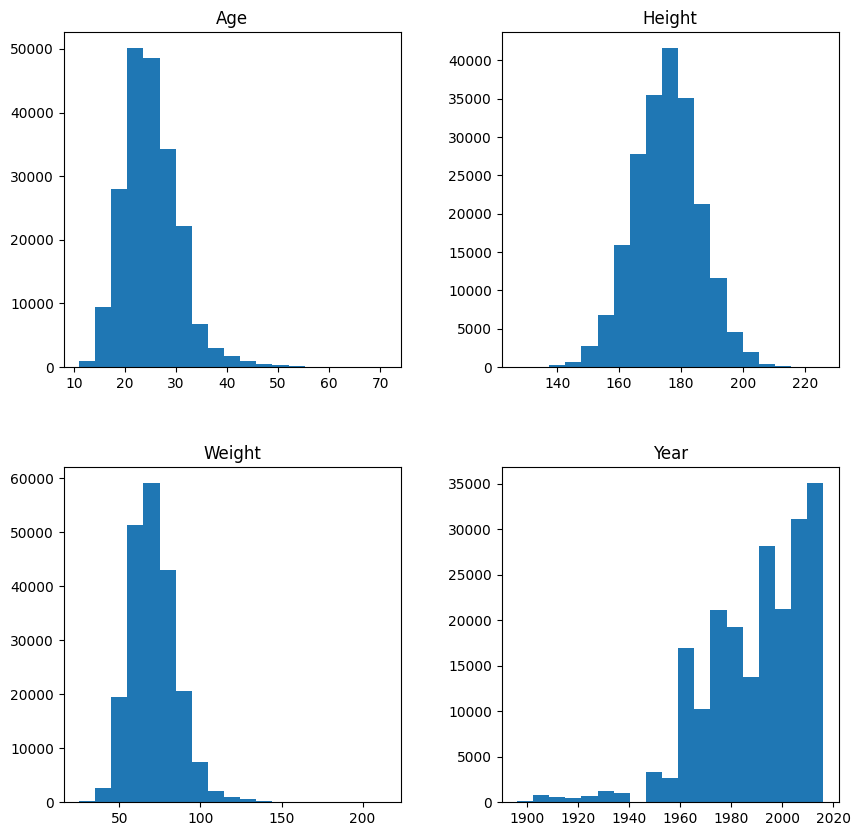

In [14]:
df.hist(figsize=(10,10), bins='sturges', grid=False);

Haga análisis bivariados entre las variables de su dataset y la variable objetivo, e identifique que variables serían potencialmente buenas predictoras y cuales no.

Reporte sus resultados en una celda de texto.

In [15]:
df.select_dtypes(include='number').corr(method='spearman')

,Age,Height,Weight,Year
Age,1.000000,0.147883,0.216915,0.125421
Height,0.147883,1.000000,0.827072,0.051190
Weight,0.216915,0.827072,1.000000,0.009172
Year,0.125421,0.051190,0.009172,1.000000


Height es buena predictora; Age tiene relación débil con Weight; Year no tiene ninguna relación.

In [16]:
vars = ['Sex', 'Season', 'Medal']

for var in vars:
  print(f'Variable: {var}')
  print(df.groupby(var)['Weight'].describe())
  print('\n')

Variable: Sex
        count       mean        std   min   25%   50%   75%    max
Sex                                                               
F     66694.0  60.023870  10.209473  25.0  54.0  59.0  65.0  167.0
M    141183.0  75.744388  13.218316  28.0  67.0  74.0  83.0  214.0


Variable: Season
           count       mean        std   min   25%   50%   75%    max
Season                                                               
Summer  168402.0  70.688489  14.807746  25.0  60.0  70.0  79.0  214.0
Winter   39475.0  70.752856  12.213663  32.0  62.0  70.0  79.0  145.0


Variable: Medal
             count       mean        std   min   25%   50%   75%    max
Medal                                                                  
Bronze     10216.0  73.476002  15.023394  28.0  63.0  72.0  82.0  182.0
Gold       10236.0  74.172089  15.208377  28.0  63.0  73.0  83.0  170.0
No medal  177472.0  70.175905  14.167151  25.0  60.0  69.0  78.0  214.0
Silver      9953.0  73.639857  14.814511 

Sex es buena predictora; Medal tiene baja relación; Season no tiene ninguna relación.

## Procesamiento de las características y entrenamiento del modelo

Cree el matriz de características $X$ con todos las variables no descartadas de su dataframe, menos la variable **Weight**, que será su variable objetivo $y$.

Particione los datos en subconjuntos de entrenamiento y prueba, en un relacion 80/20, usando `random_state=1`.

Para una primera versión de su modelo, seleccione 5 características a procesar que, de acuerdo con el análisis exploratorio realizado, parezcan ser buenas predictoras. Dentro de las 5 debe haber al menos una característica ordinal y dos nominales.

Empaquete las transformaciones que aplicará a estas características usando `ColumnTransformer`. Use el parámetro `remainder='drop'`para descartar las variables que no va a procesar.

Para el modelado va a usar un modelo de regresión lineal Ridge. Cree un flujo de trabajo que integre el procesamiento y el modelado usando `Pipeline`.

Entrene el modelo y reporte los scores de entrenamiento y de prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del paso de procesamiento.

Vuelva a entrenar el modelo, pero esta vez añada 2 características adicionales.

Reporte los scores de entrenamiento y de prueba del modelo reentrenado.

Reporte las características con las que **realmente** fue reentrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[
        'Weight'
    ])

y = df['Weight']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, train_size=0.8)  # noqa: E501
print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (166301, 11)
Tamaño del conjunto de prueba es: (41576, 11)


Variables seleccionadas:

- Height: StandardScaler
- Age: PowerTransformer
- Sex: OneHotEncoder
- Medal: OrdinalEncoder
- Sport: Target Encoder

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
  OneHotEncoder,
  OrdinalEncoder,
  PowerTransformer,
  StandardScaler,
)

ohe = OneHotEncoder(sparse_output=False, drop='if_binary', handle_unknown='ignore')
ore = OrdinalEncoder(categories=[['No medal', 'Bronze', 'Silver', 'Gold']])
ss = StandardScaler()
pt = PowerTransformer()
si = SimpleImputer(strategy='mean')
pre_age = Pipeline(steps=[
    ('si', si),
    ('pt', pt)
])
pre_height = Pipeline(steps=[
    ('si', si),
    ('ss', ss)
])

preprocessor = ColumnTransformer(transformers=[
    ('ohe', ohe, ['Sex']),
    ('ore', ore, ['Medal']),
    ('pre_age', pre_age, ['Age']),
    ('pre_height', pre_height, ['Height'])
    ],
    remainder='drop') # El resto de las columnas se mantienen sin cambios

preprocessor

,transformers,"[('ohe', ...), ('ore', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,'if_binary'
,sparse_output,False


In [19]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

clf = Ridge()

model = Pipeline([
    ('preprocessor', preprocessor),
     ('clf', clf)
    ])

model

,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ohe', ...), ('ore', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
model.fit(X_train, y_train)

print(f'R^2 score en el conjunto de entrenamiento: {model.score(X_train, y_train):.4f}')
print(f'R^2 score en el conjunto de prueba: {model.score(X_test, y_test):.4f}')

R^2 score en el conjunto de entrenamiento: 0.6563
R^2 score en el conjunto de prueba: 0.6560


In [21]:
# Añadir la variable 'Sport'

from sklearn.preprocessing import TargetEncoder

te = TargetEncoder()

preprocessor = ColumnTransformer(transformers=[
    ('ohe', ohe, ['Sex']),
    ('ore', ore, ['Medal']),
    ('pre_age', pre_age, ['Age']),
    ('pre_height', pre_height, ['Height']),
    ('te', te, ['Sport'])
    ],
    remainder='drop') # El resto de las columnas se mantienen sin cambios

preprocessor

,transformers,"[('ohe', ...), ('ore', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,'if_binary'
,sparse_output,False


In [22]:
model = Pipeline([
    ('preprocessor', preprocessor),
     ('clf', clf)
    ])

model.fit(X_train, y_train)

print(f'R^2 score en el conjunto de entrenamiento: {model.score(X_train, y_train):.4f}')
print(f'R^2 score en el conjunto de prueba: {model.score(X_test, y_test):.4f}')

R^2 score en el conjunto de entrenamiento: 0.6823
R^2 score en el conjunto de prueba: 0.6819


In [23]:
features = model.named_steps['preprocessor'].get_feature_names_out()
print(features)

['ohe__Sex_M' 'ore__Medal' 'pre_age__Age' 'pre_height__Height' 'te__Sport']


Se añadirán NOC y Event; ambos se transformarán con TargetEncoder

In [24]:
preprocessor = ColumnTransformer(transformers=[
    ('ohe', ohe, ['Sex']),
    ('ore', ore, ['Medal']),
    ('pre_age', pre_age, ['Age']),
    ('pre_height', pre_height, ['Height']),
    ('te', te, ['Sport', 'NOC', 'Event'])
    ],
    remainder='drop') # El resto de las columnas se mantienen sin cambios

model = Pipeline([
    ('preprocessor', preprocessor),
     ('clf', clf)
    ])

model.fit(X_train, y_train)

print(f'R^2 score en el conjunto de entrenamiento: {model.score(X_train, y_train):.4f}')
print(f'R^2 score en el conjunto de prueba: {model.score(X_test, y_test):.4f}')

R^2 score en el conjunto de entrenamiento: 0.8117
R^2 score en el conjunto de prueba: 0.8111


In [25]:
features = model.named_steps['preprocessor'].get_feature_names_out()
print(features)

['ohe__Sex_M' 'ore__Medal' 'pre_age__Age' 'pre_height__Height' 'te__Sport'
 'te__NOC' 'te__Event']
